In [ ]:
# --- Colab setup (auto-inserted; no-op outside Colab). tag: colab-bootstrap ---
import sys
if "google.colab" in sys.modules:
    import os, subprocess, pathlib
    _slug = "aniryou/full-stack-agentic-engineer"
    _root = pathlib.Path("/content") / "full-stack-agentic-engineer"
    if not _root.exists():
        subprocess.run(["git", "clone", "--depth", "1", f"https://github.com/{_slug}.git", str(_root)], check=True)
    os.chdir(_root / "07-application-agent-framework/retrieval-rag/embeddings-lab/solutions")
    for _c in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]:
        if (_c / "pyproject.toml").exists() or (_c / "setup.py").exists():
            subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", str(_c)]); break
        if (_c / "requirements.txt").exists():
            subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", str(_c / "requirements.txt")]); break
        if _c == _root:
            break
    if str(pathlib.Path.cwd()) not in sys.path:
        sys.path.insert(0, str(pathlib.Path.cwd()))


# Exercises 06 · Superposition mechanics
Build the toy model yourself: forward pass, gradients (checked numerically),
then run the sparsity sweep with *your* code. Solutions:
`solutions/ex06_solutions.ipynb`.

In [1]:
import numpy as np, matplotlib.pyplot as plt
rng = np.random.default_rng(0)

## Task 1 — forward pass
`x̂ = ReLU(X W Wᵀ + b)` with `X` (B,n), `W` (n,d), `b` (n,).
Check: with `W = I` (n = d) and non-negative `X`, `b = 0`, the model is the
identity.

In [2]:
def forward(X, W, b):
    H = X @ W
    Z = H @ W.T + b
    return np.maximum(Z, 0.0), Z, H

X0 = rng.random((5, 3))
Xh, _, _ = forward(X0, np.eye(3), np.zeros(3))
assert np.allclose(Xh, X0)
print("forward ✓")

forward ✓


## Task 2 — gradients (W appears twice!)
Loss: `mean_B Σᵢ Iᵢ (x̂ᵢ − xᵢ)²`. Derive `dW` and `db`. Hints:
`dZ = (2/B)·I·(x̂ − x)·1[Z>0]`; then `dW = dZᵀH + Xᵀ(dZ·W)` — one term per
appearance of `W`. The finite-difference harness below is the judge.

In [3]:
def loss_and_grads(X, W, b, I):
    Bn = len(X)
    Xh, Z, H = forward(X, W, b)
    err = Xh - X
    loss = float((I * err ** 2).mean(0).sum())
    dZ = (2.0 / Bn) * I * err * (Z > 0)
    dB = dZ.sum(0)
    dW = dZ.T @ H + X.T @ (dZ @ W)
    return loss, dW, dB

n, d, Bn = 5, 2, 7
X = (rng.random((Bn, n)) < 0.5) * rng.random((Bn, n))
W = rng.normal(size=(n, d)) * 0.5
b = rng.normal(size=n) * 0.1
I = np.linspace(1, 0.5, n)
_, dW, dB = loss_and_grads(X, W, b, I)
eps = 1e-6
for arr, g in [(W, dW), (b, dB)]:
    num = np.zeros_like(arr)
    it = np.nditer(arr, flags=["multi_index"])
    while not it.finished:
        k = it.multi_index
        old = arr[k]
        arr[k] = old + eps; lp, *_ = loss_and_grads(X, W, b, I)
        arr[k] = old - eps; lm, *_ = loss_and_grads(X, W, b, I)
        arr[k] = old
        num[k] = (lp - lm) / (2 * eps)
        it.iternext()
    assert np.abs(num - g).max() < 1e-5
print("loss_and_grads ✓ (matches finite differences)")

loss_and_grads ✓ (matches finite differences)


## Task 3 — run the phase change with your gradients
Provided training loop. Train at p = 1.0 and p = 0.05 and plot the feature
directions. You should see ~2 surviving features (dense) vs all 5 packed in
(sparse).

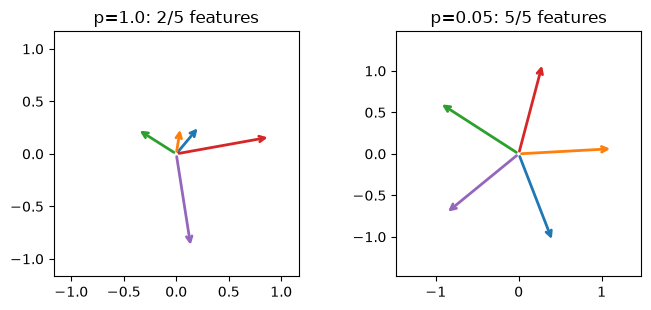

phase change ✓ — sparse inputs buy superposition


In [4]:
def train(p, n=5, d=2, steps=12000, lr=0.02, seed=0):
    r = np.random.default_rng(seed)
    W = r.normal(size=(n, d)) * 0.3
    b = np.zeros(n)
    I = np.ones(n)
    mW = vW = mB = vB = 0.0
    for t in range(1, steps + 1):
        Xb = (r.random((512, n)) < p) * r.random((512, n))
        _, dW, dB = loss_and_grads(Xb, W, b, I)
        mW = 0.9*mW + 0.1*dW; vW = 0.999*vW + 0.001*dW**2
        mB = 0.9*mB + 0.1*dB; vB = 0.999*vB + 0.001*dB**2
        lr_t = lr * 0.5 * (1 + np.cos(np.pi * t / steps))   # cosine decay
        W -= lr_t * (mW/(1-0.9**t)) / (np.sqrt(vW/(1-0.999**t)) + 1e-8)
        b -= lr_t * (mB/(1-0.9**t)) / (np.sqrt(vB/(1-0.999**t)) + 1e-8)
    return W

fig, axes = plt.subplots(1, 2, figsize=(7, 3.2))
for ax, p in zip(axes, [1.0, 0.05]):
    Wp = train(p)
    for i in range(len(Wp)):
        ax.annotate("", xy=Wp[i], xytext=(0, 0),
                    arrowprops=dict(arrowstyle="->", color=f"C{i}", lw=2))
    lim = max(1.1, np.abs(Wp).max() * 1.3)
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_aspect("equal")
    alive = int((np.linalg.norm(Wp, axis=1) > 0.6).sum())
    ax.set_title(f"p={p}: {alive}/5 features")
plt.tight_layout(); plt.show()
print("phase change ✓ — sparse inputs buy superposition")

## Task 4 (open) — capacity allocation
Rerun with importances `0.75**i` for 8 features at p=0.15. Which features get
a (near-)dedicated direction and which share? Relate to why frequent concepts
in real embedding models interfere less than rare ones.